# 1. CCBO-LogEI

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/data1/qcq4123155034/CBBO
device: cuda


/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([-0.0539], device='cuda:0', dtype=torch.float64), std = tensor([0.3607], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


------{l_i}: tensor([0.2000], device='cuda:0', dtype=torch.float64)
candidate: tensor([[0.5646],
        [0.1982],
        [0.9269],
        [1.9560],
        [0.3824]], device='cuda:0')


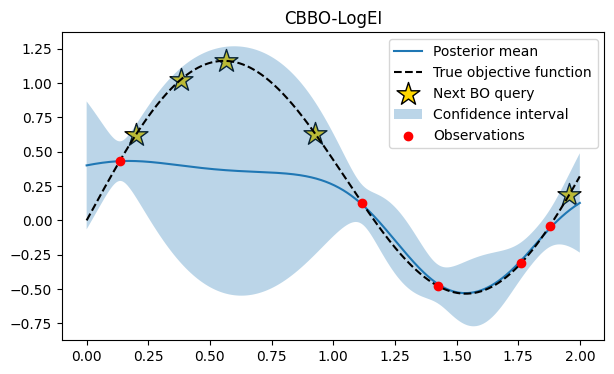

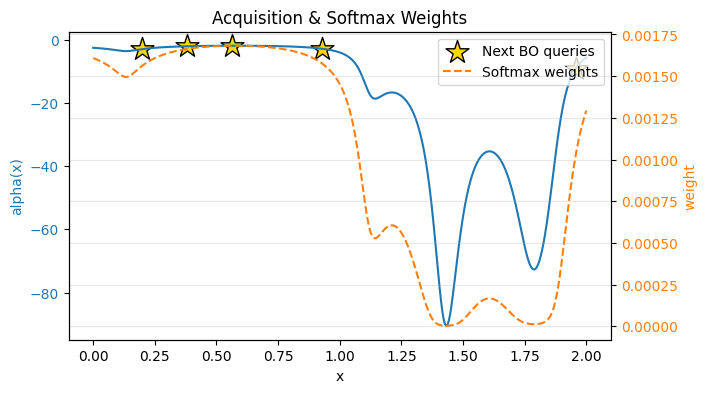

In [1]:
import torch
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.analytic import LogExpectedImprovement
from botorch.optim import optimize_acqf

from gpytorch.mlls import ExactMarginalLogLikelihood

import os
import sys
notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..', '..')) 
print(project_root)
sys.path.append(project_root)

from cbbo.cbbo import coverage_batch_bo_step


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double   
print('device:', device)

def objective(x):
    # x: (n, 1)
    return torch.sin(3 * x) + 0.3 * x

torch.manual_seed(0)

# 
bounds = torch.tensor([[0.0], [2.0]], device=device, dtype=dtype)


# Batch points
q = 5

# 
train_x = (torch.rand(5, 1, device=device, dtype=dtype) * 2.0)
train_y = objective(train_x).to(device=device, dtype=dtype)


model = SingleTaskGP(train_x, train_y)
model = model.to(device=device, dtype=dtype)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

best_f = train_y.max()

acqf = LogExpectedImprovement(
    model=model,
    best_f=best_f
).to(device=device, dtype=dtype)

# 
X = torch.linspace(0, 2, 1000, device=device, dtype=dtype).unsqueeze(-1)
X_acq = X.unsqueeze(1)   # (500, 1, 1)

# 
posterior = model.posterior(X)
mean = posterior.mean.squeeze(-1).detach()
var = posterior.variance.squeeze(-1).detach()

# 
with torch.no_grad():
    log_ei = acqf(X_acq).squeeze(-1)


candidates, _, w =  coverage_batch_bo_step(
    model=model,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=1000,
    eta_l=0.1,
    eta_tau=0.6,
    acqf_name='LogEI',
    device=device,
    best_f=best_f,
)

print('candidate:', candidates)

with torch.no_grad():
    log_ei_candidates = acqf(candidates.unsqueeze(1)).squeeze(-1)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("CBBO-LogEI")
plt.legend()
plt.show()



fig, ax1 = plt.subplots(figsize=(7, 4))

# left axix：acquisition
ax1.plot(X.cpu().numpy(), log_ei.cpu().numpy(), color='C0')
ax1.scatter(candidates.cpu().numpy(), log_ei_candidates.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X.cpu().numpy(), w.cpu().numpy(), label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Acquisition & Softmax Weights")
plt.grid(alpha=0.3)
plt.show()




# 2 CBBO-EI

------{l_i}: tensor([0.2000], device='cuda:0', dtype=torch.float64)
candidate: tensor([[0.5726],
        [0.4184],
        [0.7227],
        [0.4985],
        [0.3103]], device='cuda:0')


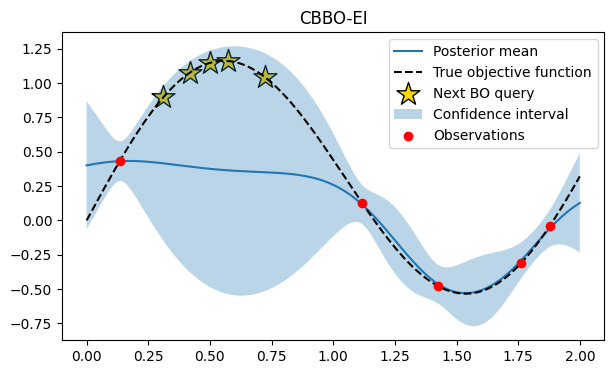

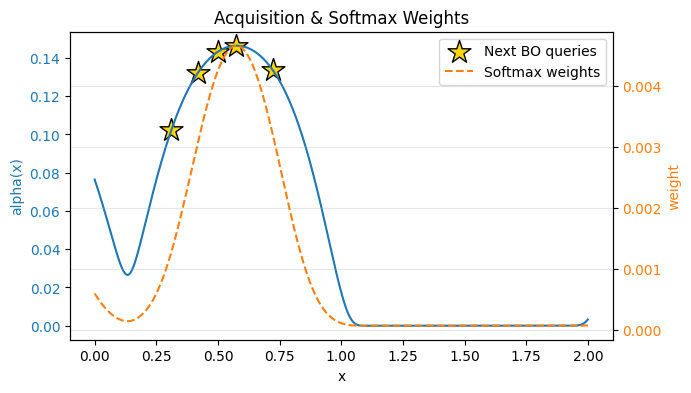

In [2]:

from botorch.acquisition.analytic import ExpectedImprovement


acqf = ExpectedImprovement(
    model=model,
    best_f=best_f
).to(device=device, dtype=dtype)

# 
with torch.no_grad():
    ei = acqf(X_acq).squeeze(-1)


candidates, _, w =  coverage_batch_bo_step(
    model=model,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=1000,
    eta_l=0.1,
    eta_tau=0.6,
    acqf_name='EI',
    device=device,
    best_f=best_f,
)

print('candidate:', candidates)

with torch.no_grad():
    ei_candidates = acqf(candidates.unsqueeze(1)).squeeze(-1)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("CBBO-EI")
plt.legend()
plt.show()



fig, ax1 = plt.subplots(figsize=(7, 4))

# left axix：acquisition
ax1.plot(X.cpu().numpy(), ei.cpu().numpy(), color='C0')
ax1.scatter(candidates.cpu().numpy(), ei_candidates.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X.cpu().numpy(), w.cpu().numpy(), label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Acquisition & Softmax Weights")
plt.grid(alpha=0.3)
plt.show()


# 3. CBBO-UCB

------{l_i}: tensor([0.2000], device='cuda:0', dtype=torch.float64)
candidate: tensor([[0.5145],
        [0.2122],
        [0.8048],
        [0.3684],
        [0.6567]], device='cuda:0')


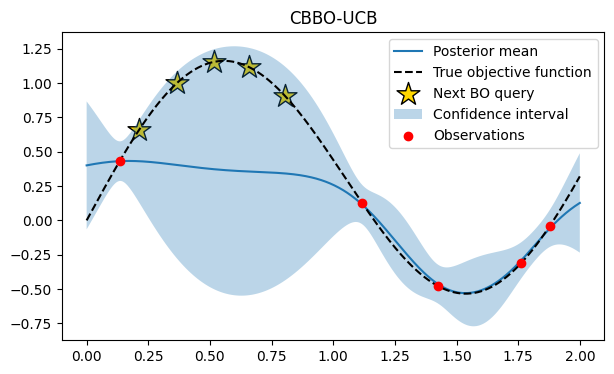

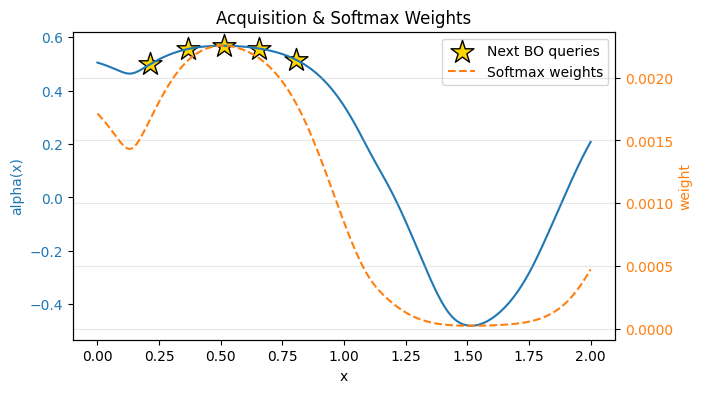

In [3]:

from botorch.acquisition.analytic import UpperConfidenceBound

beta = 0.2

acqf = UpperConfidenceBound(
    model=model,
    beta=beta,
).to(device=device, dtype=dtype)


# 
with torch.no_grad():
    ucb = acqf(X_acq).squeeze(-1)


candidates, _, w =  coverage_batch_bo_step(
    model=model,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=1000,
    eta_l=0.1,
    eta_tau=0.6,
    acqf_name='UCB',
    device=device,
    beta=beta,
)

print('candidate:', candidates)

with torch.no_grad():
    ucb_candidates = acqf(candidates.unsqueeze(1)).squeeze(-1)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("CBBO-UCB")
plt.legend()
plt.show()



fig, ax1 = plt.subplots(figsize=(7, 4))

# left axix：acquisition
ax1.plot(X.cpu().numpy(), ucb.cpu().numpy(), color='C0')
ax1.scatter(candidates.cpu().numpy(), ucb_candidates.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X.cpu().numpy(), w.cpu().numpy(), label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Acquisition & Softmax Weights")
plt.grid(alpha=0.3)
plt.show()


# 4. CBBO-KG 

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/gpytorch.py:477: BotorchTensorDimensionWarning: Non-strict enforcement of botorch tensor conventions. The following error would have been raised with strict enforcement: Expected X and Y to have the same number of dimensions (got X with dimension 3 and Y with dimension 4).
  self._validate_tensor_args(X=X, Y=Y, Yvar=noise, strict=False)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/gpytorch.py:239: BotorchTensorDimensionWarning: Non-strict enforcement of botorch tensor conventions. The following error would have been raised with strict enforcement: Expected X and Y to have the same number of dimensions (got X with dimension 3 and Y with dimension 4).
  self._validate_tensor_args(X=X, Y=Y, Yvar=Yvar, strict=False)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/gpytorch.py:477: UserWarning: The model inputs are of type torch.float32. It is 

------{l_i}: tensor([0.2000], device='cuda:0', dtype=torch.float64)
candidate: tensor([[0.3163],
        [0.7708],
        [0.1101],
        [0.5325],
        [0.9790]], device='cuda:0')


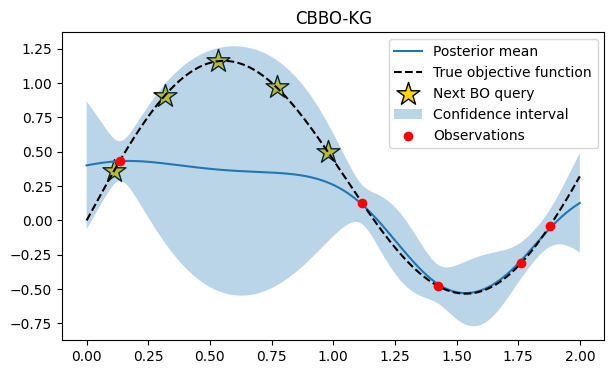

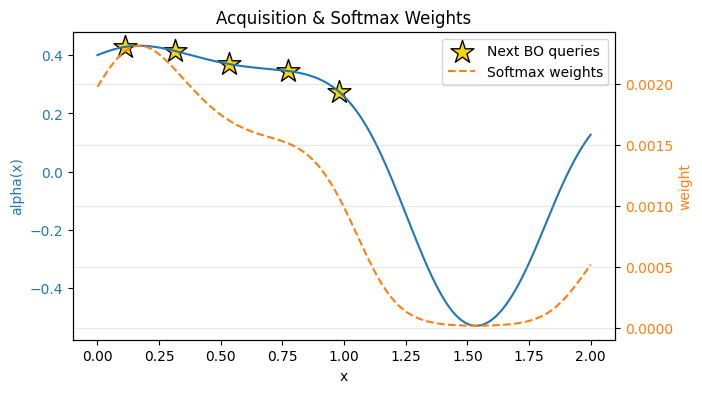

In [4]:

from botorch.acquisition.knowledge_gradient import qKnowledgeGradient

num_fantasies = 1

acqf = qKnowledgeGradient(
    model=model,
    num_fantasies=num_fantasies,
).to(device=device, dtype=dtype)


# 
with torch.no_grad():
    kg = acqf(X_acq).squeeze(-1)


candidates, _, w =  coverage_batch_bo_step(
    model=model,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=1000,
    eta_l=0.1,
    eta_tau=0.6,
    acqf_name='KG',
    device=device,
    num_fantasies=num_fantasies,
)

print('candidate:', candidates)

with torch.no_grad():
    kg_candidates = acqf(candidates.unsqueeze(1)).squeeze(-1)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("CBBO-KG")
plt.legend()
plt.show()



fig, ax1 = plt.subplots(figsize=(7, 4))

# left axix：acquisition
ax1.plot(X.cpu().numpy(), kg.cpu().numpy(), color='C0')
ax1.scatter(candidates.cpu().numpy(), kg_candidates.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X.cpu().numpy(), w.cpu().numpy(), label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Acquisition & Softmax Weights")
plt.grid(alpha=0.3)
plt.show()


# 5. CBBO-PES 

------{l_i}: tensor([0.2000], device='cuda:0', dtype=torch.float64)
candidate: tensor([[0.5666],
        [0.7808],
        [0.3724],
        [0.0340],
        [0.6707]], device='cuda:0')


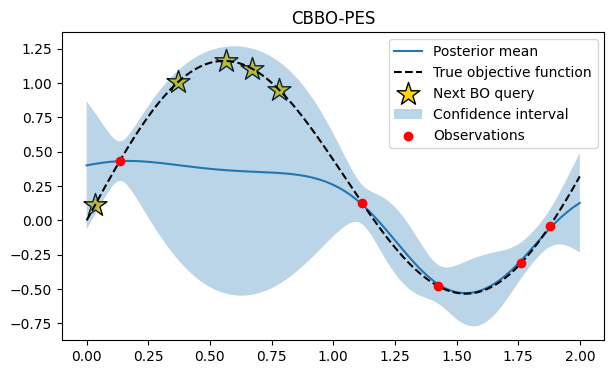

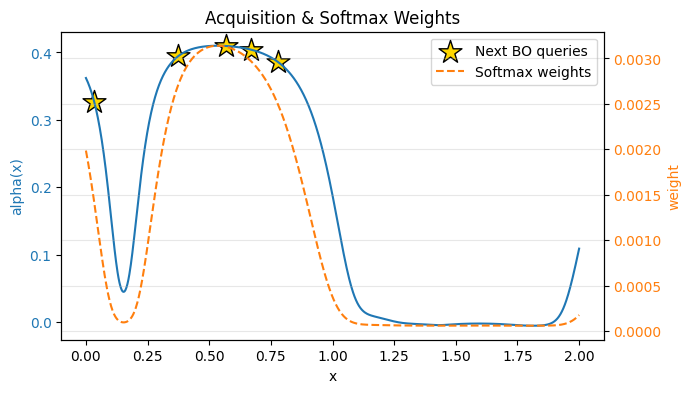

In [5]:

from botorch.acquisition.predictive_entropy_search import qPredictiveEntropySearch
from botorch.acquisition.analytic import PosteriorMean

pm = PosteriorMean(model).to(device=device, dtype=dtype)

X_star, _ = optimize_acqf(
    pm,
    bounds=bounds,
    q=1,
    num_restarts=20,
    raw_samples=256,
)

acqf = qPredictiveEntropySearch(
    model=model,
    optimal_inputs=X_star,
).to(device=device, dtype=dtype)


# 
with torch.no_grad():
    pes = acqf(X_acq).squeeze(-1)

candidates, _, w =  coverage_batch_bo_step(
    model=model,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=1000,
    eta_l=0.1,
    eta_tau=0.6,
    acqf_name='PES',
    device=device,
    optimal_inputs=X_star,
)

print('candidate:', candidates)

with torch.no_grad():
    pes_candidates = acqf(candidates.unsqueeze(1)).squeeze(-1)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("CBBO-PES")
plt.legend()
plt.show()



fig, ax1 = plt.subplots(figsize=(7, 4))

# left axix：acquisition
ax1.plot(X.cpu().numpy(), pes.cpu().numpy(), color='C0')
ax1.scatter(candidates.cpu().numpy(), pes_candidates.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X.cpu().numpy(), w.cpu().numpy(), label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Acquisition & Softmax Weights")
plt.grid(alpha=0.3)
plt.show()


# 6. CBBO-MES

------{l_i}: tensor([0.2000], device='cuda:0', dtype=torch.float64)
candidate: tensor([[0.6006],
        [0.6547],
        [0.5465],
        [0.6266],
        [0.5746]], device='cuda:0')


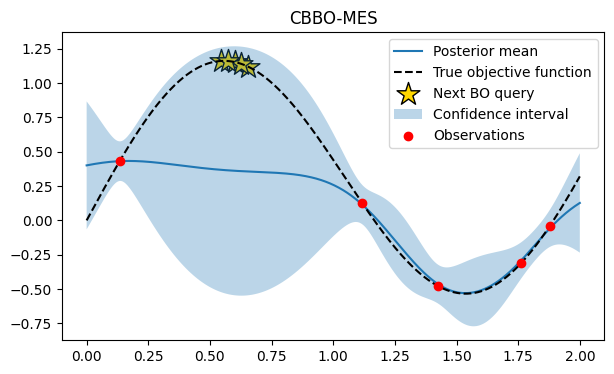

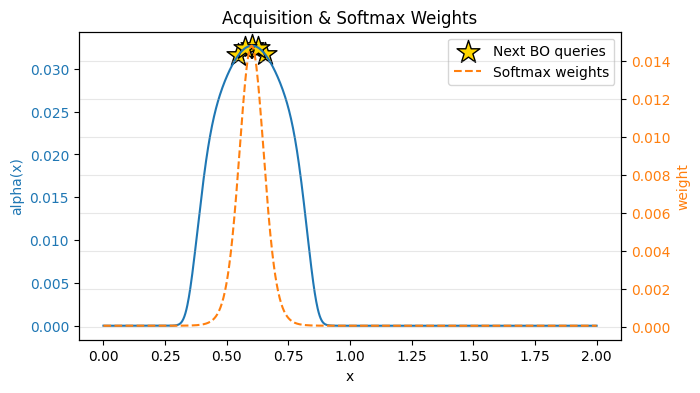

In [6]:
from botorch.acquisition.max_value_entropy_search import qMaxValueEntropy
from cbbo.discretization import discretizer

N = 1000

candidate_set = discretizer(
    discretizer_method="hypercube",
    bounds=bounds.T,
    N=N,
)

acqf = qMaxValueEntropy(
    model=model,
    candidate_set = candidate_set,
    
).to(device=device, dtype=dtype)


# 
with torch.no_grad():
    mes = acqf(X_acq).squeeze(-1)


candidates, _, w =  coverage_batch_bo_step(
    model=model,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=N,
    eta_l=0.1,
    eta_tau=0.6,
    acqf_name='MES',
    device=device,
    candidate_set=candidate_set,
)

print('candidate:', candidates)

with torch.no_grad():
    mes_candidates = acqf(candidates.unsqueeze(1)).squeeze(-1)


plt.figure(figsize=(7, 4))

plt.plot(X.cpu().numpy(), mean.cpu().numpy(), label="Posterior mean")
plt.plot(X.cpu().numpy(), objective(X).cpu().numpy(), label='True objective function', color='black', linestyle='--')
plt.scatter(candidates.cpu().numpy(), objective(candidates).cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO query')
plt.fill_between(
    X.squeeze().cpu().numpy(),
    (mean - 2 * var.sqrt()).cpu().numpy(),
    (mean + 2 * var.sqrt()).cpu().numpy(),
    alpha=0.3,
    label="Confidence interval"
)

plt.scatter(train_x.cpu().numpy(), train_y.cpu().numpy(), color="red", zorder=3, label="Observations")

plt.title("CBBO-MES")
plt.legend()
plt.show()



fig, ax1 = plt.subplots(figsize=(7, 4))

# left axix：acquisition
ax1.plot(X.cpu().numpy(), mes.cpu().numpy(), color='C0')
ax1.scatter(candidates.cpu().numpy(), mes_candidates.cpu().numpy(), marker='*', s=300, c='gold', edgecolors='black', label='Next BO queries')
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# rigjt axix：softmax weights
ax2 = ax1.twinx()
ax2.plot(X.cpu().numpy(), w.cpu().numpy(), label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

#  legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Acquisition & Softmax Weights")
plt.grid(alpha=0.3)
plt.show()


# 7. CBBO-EEBO

/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:174: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/data2/qcq4123155034/conda_envs/beebo/lib/python3.9/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning: Input data is not standardized (mean = tensor([-29.7538], device='cuda:0', dtype=torch.float64), std = tensor([24.2022], device='cuda:0', dtype=torch.float64)). Please consider scaling the input to zero mean and unit variance.
  warnings.warn(msg, InputDataWarning)


------{l_i}: tensor([1.5000, 1.5000], device='cuda:0', dtype=torch.float64)
candidate: tensor([[3.2258, 1.4516],
        [9.0323, 4.8387],
        [4.1935, 3.3871],
        [3.7097, 1.4516],
        [4.1935, 2.9032]], device='cuda:0')
tensor([-28.3143, -28.6557, -28.7885, -28.8296, -28.9414], device='cuda:0',
       dtype=torch.float64)


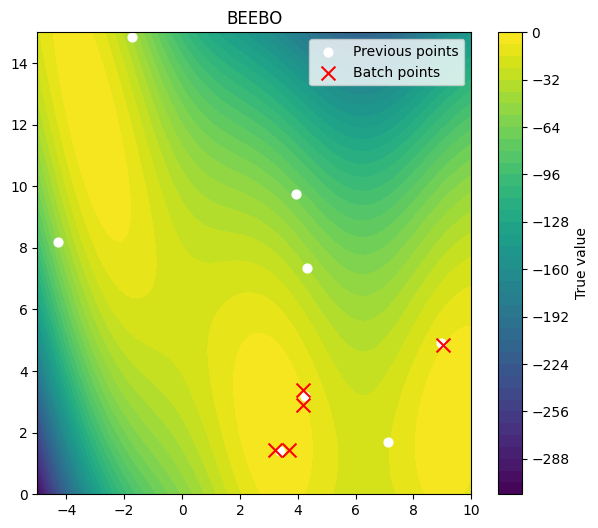

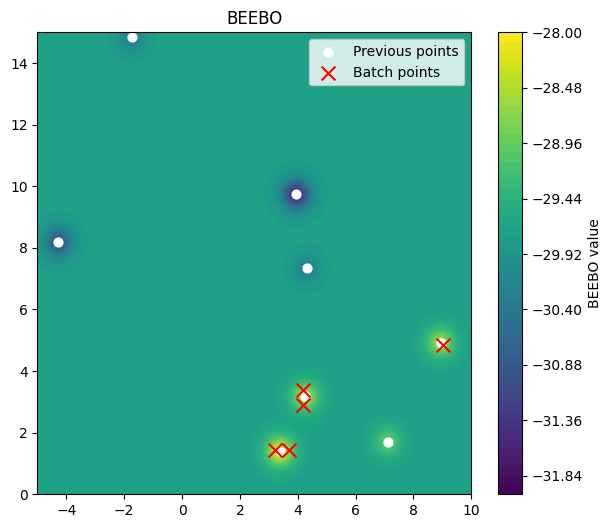

In [ ]:
from beebo import BatchedEnergyEntropyBO
from botorch.test_functions import Branin

branin = Branin(negate=True).to(device=device, dtype=dtype)
bounds = branin.bounds.to(device=device, dtype=dtype)


n_init = 8
train_X = bounds[0] + (bounds[1] - bounds[0]) * torch.rand(n_init, 2, device=device, dtype=dtype)
train_X = train_X.to(device=device, dtype=dtype)
train_Y = branin(train_X).unsqueeze(-1)
train_Y = train_Y.to(device=device, dtype=dtype)

# ========== 2. Grid (for plotting true function) ==========
grid_size = 100
x1 = torch.linspace(bounds[0, 0], bounds[1, 0], grid_size, device=device, dtype=dtype)
x2 = torch.linspace(bounds[0, 1], bounds[1, 1], grid_size, device=device, dtype=dtype)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
X_grid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=-1)
Y_true = branin(X_grid).reshape(grid_size, grid_size).to(device=device, dtype=dtype)


model = SingleTaskGP(train_X, train_Y).to(device=device, dtype=dtype)
mll = ExactMarginalLogLikelihood(model.likelihood, model).to(device=device, dtype=dtype)
fit_gpytorch_mll(mll).to(device=device, dtype=dtype)


temperature = 1.0

acqf = BatchedEnergyEntropyBO(
    model=model,
    temperature=temperature
).to(device=device, dtype=dtype)


with torch.no_grad():
    eebo_grid = acqf(X_grid.unsqueeze(1))

eebo_grid = eebo_grid.view(grid_size, grid_size)

candidates, _, w =  coverage_batch_bo_step(
    model=model,
    bounds=bounds,
    q=q,
    discretizer_methods='hypercube',
    N=1000,
    eta_l=0.1,
    eta_tau=0.6,
    acqf_name='EE',
    device=device,
    temperature=temperature,
)

print('candidate:', candidates)

with torch.no_grad():
    eebo_candidates = acqf(candidates.unsqueeze(1)).squeeze(-1)
    print(eebo_candidates)


plt.figure(figsize=(7, 6))
cs_1 = plt.contourf(X1.cpu().numpy(), X2.cpu().numpy(), Y_true.cpu().numpy(), levels=50, cmap="viridis")
plt.colorbar(cs_1, label="True value")
plt.scatter(
    train_X[:, 0].cpu().numpy(),
    train_X[:, 1].cpu().numpy(),
    c="white",
    s=40,
label="Previous points",
)
plt.scatter(
    candidates[:, 0].cpu().numpy(),
    candidates[:, 1].cpu().numpy(),
    marker="x",
    s=100,
    c='red',
    label="Batch points",
)
plt.legend()
plt.title("CBBO-EE")
plt.show()

plt.figure(figsize=(7, 6))
cs_2 = plt.contourf(X1.cpu().numpy(), X2.cpu().numpy(), eebo_grid.cpu().numpy(), levels=50, cmap="viridis")
plt.colorbar(cs_2, label="BEEBO value")
plt.scatter(
    train_X[:, 0].cpu().numpy(),
    train_X[:, 1].cpu().numpy(),
    c="white",
    s=40,
label="Previous points",
)
plt.scatter(
    candidates[:, 0].cpu().numpy(),
    candidates[:, 1].cpu().numpy(),
    marker="x",
    s=100,
    c='red',
    label="Batch points",
)
plt.legend()
plt.title("BEEBO")
plt.show()

